In [1]:
import os
import pandas as pd

BASE_DIR = "."

## Filtrado

In [8]:
FILE_PATH = os.path.join(BASE_DIR, "bbdd_filtrada.csv")
chunk_size = 1000000
store_nbr = 44

tamano_gb = os.path.getsize(FILE_PATH) / (1024**3)
print(f"Tamaño en disco: {tamano_gb:.2f} GB")

Tamaño en disco: 0.22 GB


In [9]:
partes = []

for i, chunk in enumerate(pd.read_csv(FILE_PATH, chunksize=chunk_size, parse_dates=["date"])):
    partes.append(chunk[chunk["store_nbr"] == store_nbr])

    if (i + 1) % 5 == 0:
        print(f"Procesadas {(i + 1) * chunk_size:,} filas leídas del archivo...")

bbdd_filtrada = pd.concat(partes, ignore_index=True)
print(f"\nFilas de la tienda 44: {len(bbdd_filtrada):,}")



Filas de la tienda 44: 1,599,702


## Revisión rápida

In [ ]:
# Selección de columnas relevantes
columnas_mantener = [
    "date",
    "item_nbr",
    "family",
    "class",
    "unit_sales",
    "onpromotion",
    "transactions",
    "perishable",
    "dcoilwtico",
    "is_holiday",
    "holiday_type",
    "transferred"
]

# Creamos el dataset limpio reduciendo las columnas innecesarias
datos_tienda44 = bbdd_filtrada[columnas_mantener].copy()

In [33]:
datos_tienda44.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599702 entries, 0 to 1599701
Data columns (total 12 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   date          1599702 non-null  datetime64[us]
 1   item_nbr      1599702 non-null  int64         
 2   family        1599702 non-null  str           
 3   class         1599702 non-null  int64         
 4   unit_sales    1599702 non-null  float64       
 5   onpromotion   1599702 non-null  bool          
 6   transactions  1594596 non-null  float64       
 7   perishable    1599702 non-null  int64         
 8   dcoilwtico    1599702 non-null  float64       
 9   is_holiday    1599702 non-null  bool          
 10  holiday_type  1599702 non-null  str           
 11  transferred   1599702 non-null  bool          
dtypes: bool(3), datetime64[us](1), float64(3), int64(3), str(2)
memory usage: 114.4 MB


## Filtro de holidays (is_holiday) y relleno de oil (dcoilwtico)


In [59]:
# --- Relleno de dcoilwtico (precio del petróleo) ---
# El petróleo no cotiza fines de semana/feriados, por eso hay NaN en esas fechas.
# Se ordena por fecha y se aplica forward-fill (arrastra el último valor conocido);
# se agrega un backward-fill solo por si la serie empieza con NaN (sin dato previo).
datos_tienda44 = datos_tienda44.sort_values("date").reset_index(drop=True)

n_nulos_antes = datos_tienda44["dcoilwtico"].isna().sum()

datos_tienda44["dcoilwtico"] = datos_tienda44["dcoilwtico"].ffill()
datos_tienda44["dcoilwtico"] = datos_tienda44["dcoilwtico"].bfill()

n_nulos_despues = bbdd_filtrada["dcoilwtico"].isna().sum()
print(f"Nulos en dcoilwtico antes: {n_nulos_antes:,}")
print(f"Nulos en dcoilwtico después: {n_nulos_despues:,}")


Nulos en dcoilwtico antes: 0
Nulos en dcoilwtico después: 0


In [60]:
# Revisión rápida del resultado
datos_tienda44[["date", "holiday_type", "is_holiday", "dcoilwtico"]].head(10)


,date,holiday_type,is_holiday,dcoilwtico
0,2016-01-02,no_holiday,False,36.81
1,2016-01-02,no_holiday,False,36.81
2,2016-01-02,no_holiday,False,36.81
3,2016-01-02,no_holiday,False,36.81
4,2016-01-02,no_holiday,False,36.81
5,2016-01-02,no_holiday,False,36.81
6,2016-01-02,no_holiday,False,36.81
7,2016-01-02,no_holiday,False,36.81
8,2016-01-02,no_holiday,False,36.81
9,2016-01-02,no_holiday,False,36.81


C:\Users\56934\AppData\Local\Temp\ipykernel_24484\1802448278.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promo_pct.index, y=promo_pct.values, ax=axes[0, 0], palette="Blues_d")
C:\Users\56934\AppData\Local\Temp\ipykernel_24484\1802448278.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(["Sin Promoción (False)", "En Promoción (True)"])
C:\Users\56934\AppData\Local\Temp\ipykernel_24484\1802448278.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=holiday_pct.index, y=holiday_pct.values, ax=axes[0, 1], palette="Greens_d")
C:\Users\

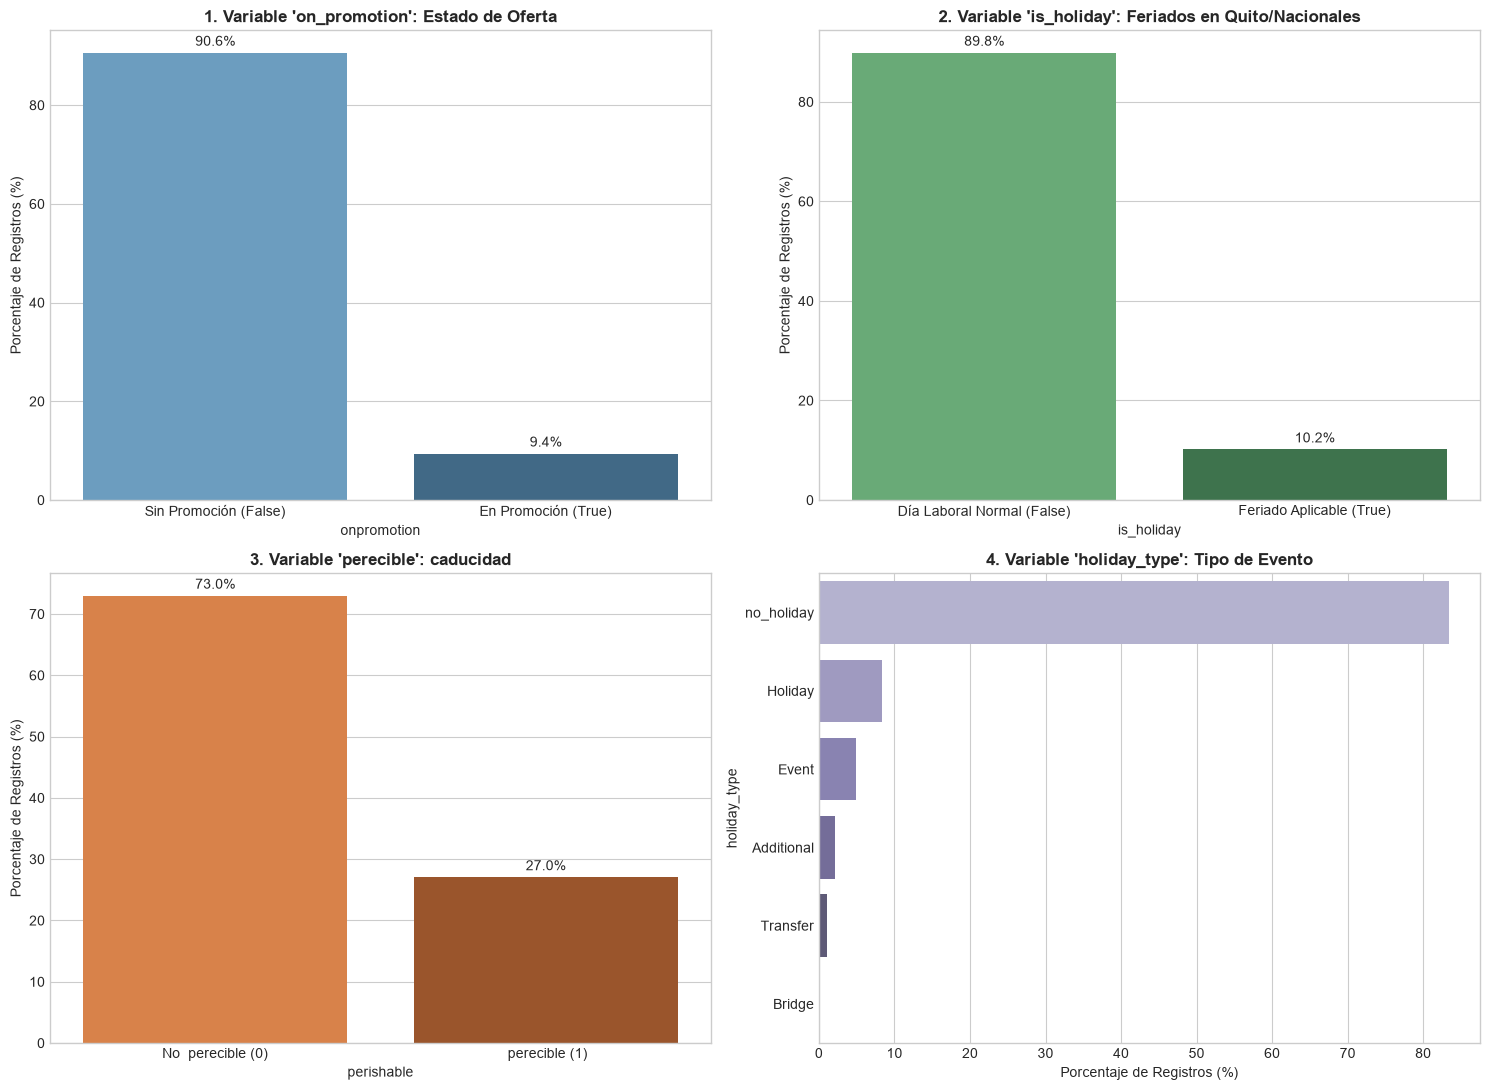

In [ ]:
#muestra que tiene cada variable
# Configuración del estilo del gráfico
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 11))


# 1. Variable: Promociones
# Explica: Porcentaje de registros de venta que tenían oferta activa
promo_pct = datos_tienda44["onpromotion"].value_counts(normalize=True) * 100
sns.barplot(x=promo_pct.index, y=promo_pct.values, ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("1. Variable 'on_promotion': Estado de Oferta", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Porcentaje de Registros (%)")
axes[0, 0].set_xticklabels(["Sin Promoción (False)", "En Promoción (True)"])

# Agregar etiquetas de porcentaje sobre las barras
for bar in axes[0, 0].patches:
    axes[0, 0].annotate(f"{bar.get_height():.1f}%", 
                        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# 2. Variable: Feriados
# Explica: Porcentaje de registros que ocurrieron en días festivos de Quito
holiday_pct = datos_tienda44["is_holiday"].value_counts(normalize=True) * 100
sns.barplot(x=holiday_pct.index, y=holiday_pct.values, ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("2. Variable 'is_holiday': Feriados en Quito/Nacionales", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Porcentaje de Registros (%)")
axes[0, 1].set_xticklabels(["Día Laboral Normal (False)", "Feriado Aplicable (True)"])

for bar in axes[0, 1].patches:
    axes[0, 1].annotate(f"{bar.get_height():.1f}%", 
                        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# 3. Variable: PERECIBLES 
# Explica: Tipo de producto según su sensibilidad a la caducidad
perish_pct = datos_tienda44["perishable"].value_counts(normalize=True) * 100
sns.barplot(x=perish_pct.index, y=perish_pct.values, ax=axes[1, 0], palette="Oranges_d")
axes[1, 0].set_title("3. Variable 'perecible': caducidad", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Porcentaje de Registros (%)")
axes[1, 0].set_xticklabels(["No  perecible (0)", " perecible (1)"])

for bar in axes[1, 0].patches:
    axes[1, 0].annotate(f"{bar.get_height():.1f}%", 
                        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# 4. Variable: tipo de evento 
# Explica: Distribución del tipo específico de festividad
type_pct = datos_tienda44["holiday_type"].value_counts(normalize=True) * 100
sns.barplot(x=type_pct.values, y=type_pct.index, ax=axes[1, 1], palette="Purples_d")
axes[1, 1].set_title("4. Variable 'holiday_type': Tipo de Evento", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Porcentaje de Registros (%)")

plt.tight_layout()
plt.show()

In [35]:
datos_tienda44.head(10)

,date,item_nbr,family,class,unit_sales,onpromotion,transactions,perishable,dcoilwtico,is_holiday,holiday_type,transferred
0,2016-01-02,103520,GROCERY I,1028,8.0,False,4539.0,0,36.81,False,no_holiday,False
1,2016-01-02,105575,GROCERY I,1045,47.0,False,4539.0,0,36.81,False,no_holiday,False
2,2016-01-02,105577,GROCERY I,1045,1.0,False,4539.0,0,36.81,False,no_holiday,False
3,2016-01-02,105693,GROCERY I,1034,4.0,False,4539.0,0,36.81,False,no_holiday,False
4,2016-01-02,105737,GROCERY I,1044,32.0,False,4539.0,0,36.81,False,no_holiday,False
5,2016-01-02,105857,GROCERY I,1092,24.0,False,4539.0,0,36.81,False,no_holiday,False
6,2016-01-02,106716,GROCERY I,1032,9.0,False,4539.0,0,36.81,False,no_holiday,False
7,2016-01-02,108634,GROCERY I,1075,38.0,False,4539.0,0,36.81,False,no_holiday,False
8,2016-01-02,105574,GROCERY I,1045,22.0,False,4539.0,0,36.81,False,no_holiday,False
9,2016-01-02,108696,DELI,2636,11.0,False,4539.0,1,36.81,False,no_holiday,False


# Mas optimo para el objetivo de la tesis.

In [61]:
# Detalle de frecuencias para las categóricas más relevantes
cols_categoricas_clave = [
    "family", "store_type", "city", "state",
    "holiday_type", "locale", "locale_name",
    "is_holiday", "onpromotion", "transferred"
]

for col in cols_categoricas_clave:
    if col in bbdd_filtrada.columns:
        print(f"\n--- {col} ---")
        print(bbdd_filtrada[col].value_counts(dropna=False))



--- family ---
family
GROCERY I                     527210
BEVERAGES                     243800
CLEANING                      180488
PRODUCE                       130852
DAIRY                         116425
BREAD/BAKERY                   57304
PERSONAL CARE                  57283
HOME CARE                      44627
DELI                           41010
MEATS                          30519
POULTRY                        25745
FROZEN FOODS                   20688
EGGS                           18187
LIQUOR,WINE,BEER               16009
HOME AND KITCHEN I             13815
HOME AND KITCHEN II             9413
PREPARED FOODS                  8391
CELEBRATION                     7973
LADIESWEAR                      6970
PLAYERS AND ELECTRONICS         6438
PET SUPPLIES                    5354
AUTOMOTIVE                      4696
GROCERY II                      4296
SEAFOOD                         4021
BEAUTY                          3804
LINGERIE                        3522
SCHOOL AND OFFI

# conservar las que aparecen mas veces en las transacciones por cada categoria

C:\Users\56934\AppData\Local\Temp\ipykernel_24484\4229955916.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_families.values, y=top_families.index, palette="viridis")


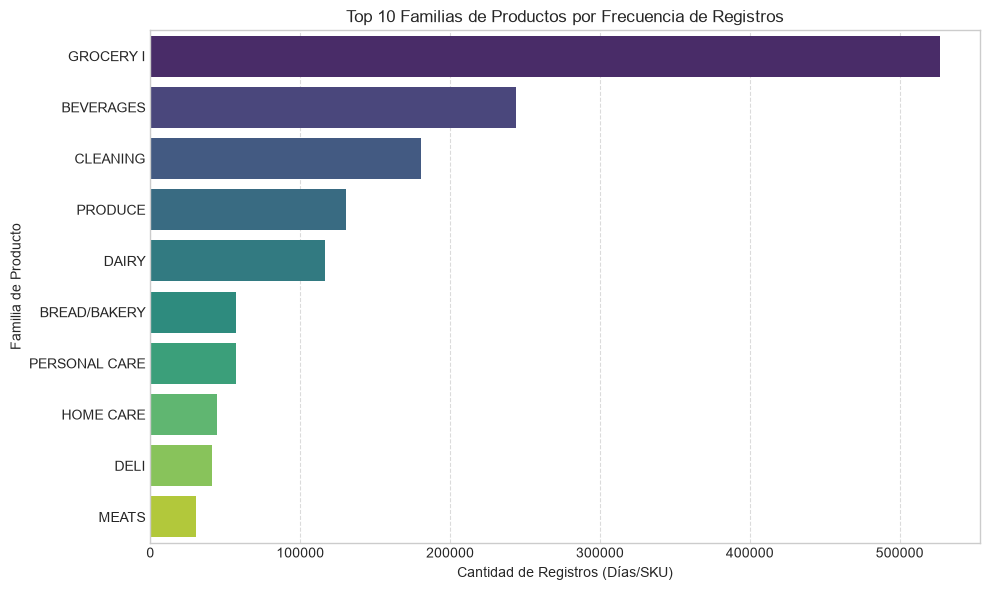

In [62]:
plt.figure(figsize=(10, 6))
# Tomamos las 10 familias más frecuentes
top_families = bbdd_filtrada["family"].value_counts().head(10)

sns.barplot(x=top_families.values, y=top_families.index, palette="viridis")
plt.title("Top 10 Familias de Productos por Frecuencia de Registros")
plt.xlabel("Cantidad de Registros (Días/SKU)")
plt.ylabel("Familia de Producto")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#  FILTRADO DE SKUs POR REGLA DE PARETO

# 1. 5 categorías principales DEFINIDAS
top_5_categorias = ["GROCERY I", "BEVERAGES", "CLEANING", "PRODUCE", "DAIRY"]

# 2. Lista para almacenar las tablas filtradas por cada categoría
lista_dfs_filtrados = []

# 3. Iteramos categoría por categoría para extraer sus SKUs según la regla del 75%
for familia in top_5_categorias:
    # Subconjunto de la categoría actual
    df_fam = bbdd_filtrada[bbdd_filtrada["family"] == familia].copy()
    
    # Conteo de frecuencia de cada SKU en esta categoría
    conteo_sku = df_fam["item_nbr"].value_counts().reset_index()
    conteo_sku.columns = ["item_nbr", "frecuencia"]
    
    # Cálculo del porcentaje acumulado (Pareto)
    conteo_sku["pct_acumulado"] = (conteo_sku["frecuencia"].cumsum() / conteo_sku["frecuencia"].sum()) * 100
    
    # Filtramos los SKUs que acumulan hasta el 75%
    skus_retenidos = conteo_sku[conteo_sku["pct_acumulado"] <= 75]["item_nbr"].tolist()
    
    # Si ningún SKU queda bajo el 75% de golpe, retenemos al menos el #1
    if not skus_retenidos:
        skus_retenidos = conteo_sku.head(1)["item_nbr"].tolist()
        
    # Guardamos solo los registros de los SKUs seleccionados
    df_fam_filtrado = df_fam[df_fam["item_nbr"].isin(skus_retenidos)]
    lista_dfs_filtrados.append(df_fam_filtrado)

# 4. Unimos todas las categorías filtradas en un único DataFrame definitivo
import pandas as pd
bbdd_final_75 = pd.concat(lista_dfs_filtrados, ignore_index=True)

# VERIFICACIÓN DE RESULTADOS
print("--- RESUMEN DEL FILTRADO DE PARETO (75%) ---")
print(f"Registros en dataset inicial (Tienda 44): {len(bbdd_filtrada):,}")
print(f"Registros tras el filtro del 75%:         {len(bbdd_final_75):,}")
print(f"SKUs únicos retenidos en total:          {bbdd_final_75['item_nbr'].nunique()}")

# Tabla detallada para la Tesis sin errores de índice
resumen_pareto = bbdd_final_75.groupby("family", as_index=False)["item_nbr"].nunique()
resumen_pareto.columns = ["Familia de Producto", "SKUs Retenidos (75% Pareto)"]
display(resumen_pareto)

--- RESUMEN DEL FILTRADO DE PARETO (75%) ---
Registros en dataset inicial (Tienda 44): 1,599,702
Registros tras el filtro del 75%:         897,783
SKUs únicos retenidos en total:          1617


,Familia de Producto,SKUs Retenidos (75% Pareto)
0,BEVERAGES,342
1,CLEANING,247
2,DAIRY,151
3,GROCERY I,706
4,PRODUCE,171


## NULOS Y DUPLICADOS

In [71]:
# Nulos por columna
nulos = bbdd_final_75.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Columnas con valores nulos:")
print(nulos)

Columnas con valores nulos:
transactions    3010
dtype: int64


In [72]:
# Duplicados considerando toda la fila
n_duplicados_totales = bbdd_final_75.duplicated().sum()
print(f"Filas completamente duplicadas: {n_duplicados_totales:,}")

Filas completamente duplicadas: 0


In [ ]:
# 1. Calculamos la media y la desviación estándar global de ventas
#media_ventas = datos_tienda44["unit_sales"].mean()
#desviacion_ventas = datos_tienda44["unit_sales"].std()

# 2. Aplicamos la fórmula del Z-Score
#datos_tienda44["unit_sales_zscore"] = (datos_tienda44["unit_sales"] - media_ventas) / desviacion_ventas

# 3. Vista previa del resultado
#print(datos_tienda44[["unit_sales", "unit_sales_zscore"]].head())

   unit_sales  unit_sales_zscore
0         8.0          -0.234319
1        47.0           0.805572
2         1.0          -0.420965
3         4.0          -0.340974
4        32.0           0.405614


In [ ]:
# 1. Obtenemos el valor mínimo y máximo de ventas de todo el dataset
#min_ventas = datos_tienda44["unit_sales"].min()
#max_ventas = datos_tienda44["unit_sales"].max()

# 2. Aplicamos la fórmula Min-Max
#datos_tienda44["unit_sales_minmax"] = (datos_tienda44["unit_sales"] - min_ventas) / (max_ventas - min_ventas)

# 3. Vista previa del resultado
#print(datos_tienda44[["unit_sales", "unit_sales_minmax"]].head())

   unit_sales  unit_sales_minmax
0         8.0           0.094667
1        47.0           0.104619
2         1.0           0.092881
3         4.0           0.093646
4        32.0           0.100791


In [ ]:
# 1. Calculamos el máximo histórico de ventas para cada producto (SKU / item_nbr)
#maximo_por_sku = datos_tienda44.groupby("item_nbr")["unit_sales"].transform("max")

# 2. Dividimos la venta diaria entre el máximo de su propio SKU (evitando división por cero)
#datos_tienda44["unit_sales_scaled_sku"] = datos_tienda44["unit_sales"] / maximo_por_sku.replace(0, 1)

# 3. Vista previa del resultado
#print(datos_tienda44[["item_nbr", "unit_sales", "unit_sales_scaled_sku"]].head())

   item_nbr  unit_sales  unit_sales_scaled_sku
0    103520         8.0               0.177778
1    105575        47.0               0.447619
2    105577         1.0               0.012048
3    105693         4.0               0.307692
4    105737        32.0               0.340426


In [ ]:
# Z-Score Específico por SKU 

# 1. Calculamos la media y la desviación estándar para CADA SKU individual
#media_por_sku = bbdd_final_75.groupby("item_nbr")["unit_sales"].transform("mean")
#std_por_sku = bbdd_final_75.groupby("item_nbr")["unit_sales"].transform("std")

# 2. Aplicamos la fórmula del Z-Score por SKU (evitando división por cero con replace)
#bbdd_final_75["unit_sales_zscore_sku"] = (bbdd_final_75["unit_sales"] - media_por_sku) / std_por_sku.replace(0, 1)

# 3. Vista previa del resultado
#print(bbdd_final_75[["item_nbr", "unit_sales", "unit_sales_zscore_sku"]].head())

   item_nbr  unit_sales  unit_sales_zscore_sku
0    103520         8.0               0.027312
1   1146787        10.0               0.642832
2   1397779         2.0              -0.464360
3   1386220         1.0              -1.152784
4   1390351         6.0               0.098439


In [ ]:
# ESTANDARIZACIÓN Z-SCORE POR SKU SOBRE LA BASE FILTRADA (bbdd_final_75)

# 1. Calculamos la media y la desviación estándar para CADA SKU dentro de la base reducida
media_por_sku = bbdd_final_75.groupby("item_nbr")["unit_sales"].transform("mean")
std_por_sku = bbdd_final_75.groupby("item_nbr")["unit_sales"].transform("std")

# 2. Creación de la columna estandarizada en la base final
bbdd_final_75["unit_sales_zscore_sku"] = (bbdd_final_75["unit_sales"] - media_por_sku) / std_por_sku.replace(0, 1)

# 3. Escalado por el máximo por SKU (opcional, para mantener ambas alternativas)
maximo_por_sku = bbdd_final_75.groupby("item_nbr")["unit_sales"].transform("max")
bbdd_final_75["unit_sales_scaled_sku"] = bbdd_final_75["unit_sales"] / maximo_por_sku.replace(0, 1)

# 4. Vista previa para verificar las nuevas columnas creadas
print("--- VERIFICACIÓN DE VARIABLES ESTANDARIZADAS ---")
display(bbdd_final_75[["item_nbr", "family", "unit_sales", "unit_sales_zscore_sku", "unit_sales_scaled_sku"]].head())

--- VERIFICACIÓN DE VARIABLES ESTANDARIZADAS ---


,item_nbr,family,unit_sales,unit_sales_zscore_sku,unit_sales_scaled_sku
0,103520,GROCERY I,8.0,0.027312,0.177778
1,1146787,GROCERY I,10.0,0.642832,0.192308
2,1397779,GROCERY I,2.0,-0.464360,0.095238
3,1386220,GROCERY I,1.0,-1.152784,0.062500
4,1390351,GROCERY I,6.0,0.098439,0.139535


## Estadística descriptiva

### Estadísticas descriptivas — variables numéricas

In [ ]:
# 1. Definimos una lista explícita ÚNICAMENTE con las variables cuantitativas de interés
cols_descriptiva = [
    "unit_sales", 
    "unit_sales_zscore_sku", 
    "unit_sales_scaled_sku", 
    "transactions", 
    "dcoilwtico"
]

# 2. Generamos la estadística descriptiva formateando a 4 decimales para evitar la notación científica
tabla_descriptiva_final = bbdd_final_75[cols_descriptiva].describe().T.round(4)

# 3. tabla limpia
display(tabla_descriptiva_final)

,count,mean,std,min,25%,50%,75%,max
unit_sales,897783.0,20.3960,42.9149,-363.0000,5.0000,10.0000,21.0000,3009.0000
unit_sales_zscore_sku,897783.0,0.0000,0.9991,-15.8712,-0.6018,-0.1913,0.3738,23.7345
unit_sales_scaled_sku,897783.0,0.1958,0.1651,-0.9791,0.0687,0.1538,0.2785,1.0000
transactions,894773.0,4367.8375,693.3521,3018.0000,3840.0000,4232.0000,4802.0000,8307.0000
dcoilwtico,897783.0,45.6354,6.3689,26.1900,43.3900,46.9700,49.7600,54.4800


In [ ]:
### VARIABLE TRANSACTIONS EXISTEN VACIOS (TRANSACTIONS/ UNIT_SALES_SKU) ESO PUEDE SER POR QUE UN DIA NO HAY VENTAS O POR QUE LA TIENDA CERRÓ? SE DEBEN RELLENAR O ELIMINAR?


### Estadísticas descriptivas — variables categóricas / booleanas

In [88]:
# 1. Variables categóricas clave
cols_categoricas_final = ["onpromotion", "family", "holiday_type", "is_holiday"]

# 2. Generamos la descriptiva base
tabla_cat = bbdd_final_75[cols_categoricas_final].astype(str).describe().T

# 3. % de la categoría dominante
tabla_cat["% Dominante"] = ((tabla_cat["freq"] / tabla_cat["count"]) * 100).round(2).astype(str) + "%"

# 4. Seleccionamos y renombramos con nombres claros
tabla_cat_final = tabla_cat[["count", "unique", "top", "freq", "% Dominante"]]
tabla_cat_final.columns = [
    "Total Registros", 
    "Categorías Distintas", 
    "Valor Más Frecuente", 
    "Conteo Valor Frecuente", 
    "% Representación"
]

display(tabla_cat_final)

,Total Registros,Categorías Distintas,Valor Más Frecuente,Conteo Valor Frecuente,% Representación
onpromotion,897783,2,False,816373,90.93%
family,897783,5,GROCERY I,395352,44.04%
holiday_type,897783,6,no_holiday,747936,83.31%
is_holiday,897783,2,False,806066,89.78%


### `unit_sales` según `is_holiday` y `onpromotion`

In [89]:
# Estadísticas de unit_sales agrupadas por is_holiday
resumen_holiday = bbdd_final_75.groupby("is_holiday")["unit_sales"].agg(
    n="count", media="mean", mediana="median", desv_std="std", minimo="min", maximo="max"
)
print("unit_sales por is_holiday:")
resumen_holiday


unit_sales por is_holiday:


,n,media,mediana,desv_std,minimo,maximo
is_holiday,,,,,,
False,806066,20.073726,10.0,41.416096,-363.0,1980.0
True,91717,23.228291,11.0,54.255537,-108.0,3009.0


In [91]:
# Estadísticas de unit_sales agrupadas por onpromotion
resumen_promo = bbdd_final_75.groupby("onpromotion")["unit_sales"].agg(
    n="count", media="mean", mediana="median", desv_std="std", minimo="min", maximo="max"
)
print("unit_sales por onpromotion:")
resumen_promo


unit_sales por onpromotion:


,n,media,mediana,desv_std,minimo,maximo
onpromotion,,,,,,
False,816373,18.972424,10.0,40.289652,-363.0,3009.0
True,81410,34.671445,17.0,61.709699,-2.0,1980.0


In [92]:
# Cruce is_holiday x onpromotion: media de unit_sales en cada combinación
resumen_cruzado = bbdd_final_75.groupby(["is_holiday", "onpromotion"])["unit_sales"].agg(
    n="count", media="mean", mediana="median"
)
print("unit_sales por is_holiday x onpromotion:")
resumen_cruzado


unit_sales por is_holiday x onpromotion:


n      media  mediana
is_holiday onpromotion                            
False      False        733289  18.631630      9.0
           True          72777  34.604041     17.0
True       False         83084  21.980226     11.0
           True           8633  35.239667     18.0

Estadistica descriptiva por productos


In [96]:
# 1. Resumen descriptivo agrupado por SKU y Categoría usando ventas escaladas (0 a 1)
resumen_sku = bbdd_final_75.groupby(["item_nbr", "family"]).agg(
    frecuencia_transacciones=("unit_sales", "count"),
    media_venta_escalada=("unit_sales_scaled_sku", "mean"),
    max_venta_original=("unit_sales", "max"),
    fecha_inicio=("date", "min"),
    fecha_fin=("date", "max")
).reset_index()

# 2. SELECCIÓN CORRECTA: Top 10 SKUs por FRECUENCIA DE APARICIÓN (Regla de Pareto/Boletas)
top_10_frecuencia = resumen_sku.sort_values(by="frecuencia_transacciones", ascending=False).head(10)

print("--- TOP 10 SKUS CON MAYOR PRESENCIA EN TRANSACCIONES (REGLA DEL 75%) ---")
display(top_10_frecuencia.round(4))

--- TOP 10 SKUS CON MAYOR PRESENCIA EN TRANSACCIONES (REGLA DEL 75%) ---


C:\Users\56934\AppData\Local\Temp\ipykernel_24484\3090142175.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_10_frecuencia.round(4))


,item_nbr,family,frecuencia_transacciones,media_venta_escalada,max_venta_original,fecha_inicio,fecha_fin
1080,1418845,GROCERY I,590,0.1429,99.0,2016-01-02,2017-08-15
1594,2011399,GROCERY I,590,0.3918,35.0,2016-01-02,2017-08-15
28,119026,CLEANING,590,0.2020,101.0,2016-01-02,2017-08-15
1050,1361205,DAIRY,590,0.2429,47.0,2016-01-02,2017-08-15
681,956012,GROCERY I,590,0.3018,79.0,2016-01-02,2017-08-15
680,954805,GROCERY I,590,0.3004,50.0,2016-01-02,2017-08-15
276,410257,GROCERY I,590,0.0837,559.0,2016-01-02,2017-08-15
299,420720,DAIRY,590,0.2768,48.0,2016-01-02,2017-08-15
295,417765,CLEANING,590,0.3831,126.0,2016-01-02,2017-08-15
1262,1473406,PRODUCE,590,0.4439,169.0,2016-01-02,2017-08-15


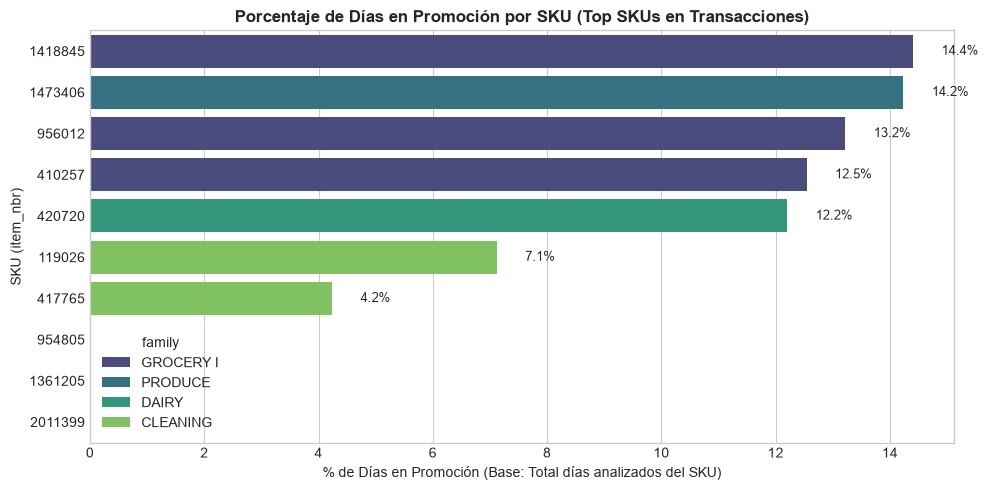

In [97]:
# 1. Calculamos el % de promoción por SKU (Denominador = Total de observaciones del SKU)
promo_sku = bbdd_final_75.groupby(["item_nbr", "family"]).agg(
    dias_totales=("onpromotion", "count"),
    dias_en_oferta=("onpromotion", lambda x: (x == True).sum())
).reset_index()

promo_sku["pct_dias_promocion"] = (promo_sku["dias_en_oferta"] / promo_sku["dias_totales"]) * 100

# 2. Tomamos los Top 10 SKUs de mayor frecuencia para graficar su nivel de promoción
top_10_ids = top_10_frecuencia["item_nbr"].tolist()
df_grafico = promo_sku[promo_sku["item_nbr"].isin(top_10_ids)].sort_values(by="pct_dias_promocion", ascending=False)

# 3. Gráfico de barras horizontal
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_grafico, 
    x="pct_dias_promocion", 
    y=df_grafico["item_nbr"].astype(str), 
    hue="family", 
    dodge=False,
    palette="viridis"
)

plt.title("Porcentaje de Días en Promoción por SKU (Top SKUs en Transacciones)", fontsize=12, fontweight="bold")
plt.xlabel("% de Días en Promoción (Base: Total días analizados del SKU)", fontsize=10)
plt.ylabel("SKU (item_nbr)", fontsize=10)

# Añadir valores porcentuales sobre las barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width + 0.5, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Produce: frutas/ verduras/alimentos frescos, de alta rotación díaria
# Beverages: aguas/ jugos / liquidos
# Grocery I: abarrotes 1ra necesidad / despensa / no perecibles 

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

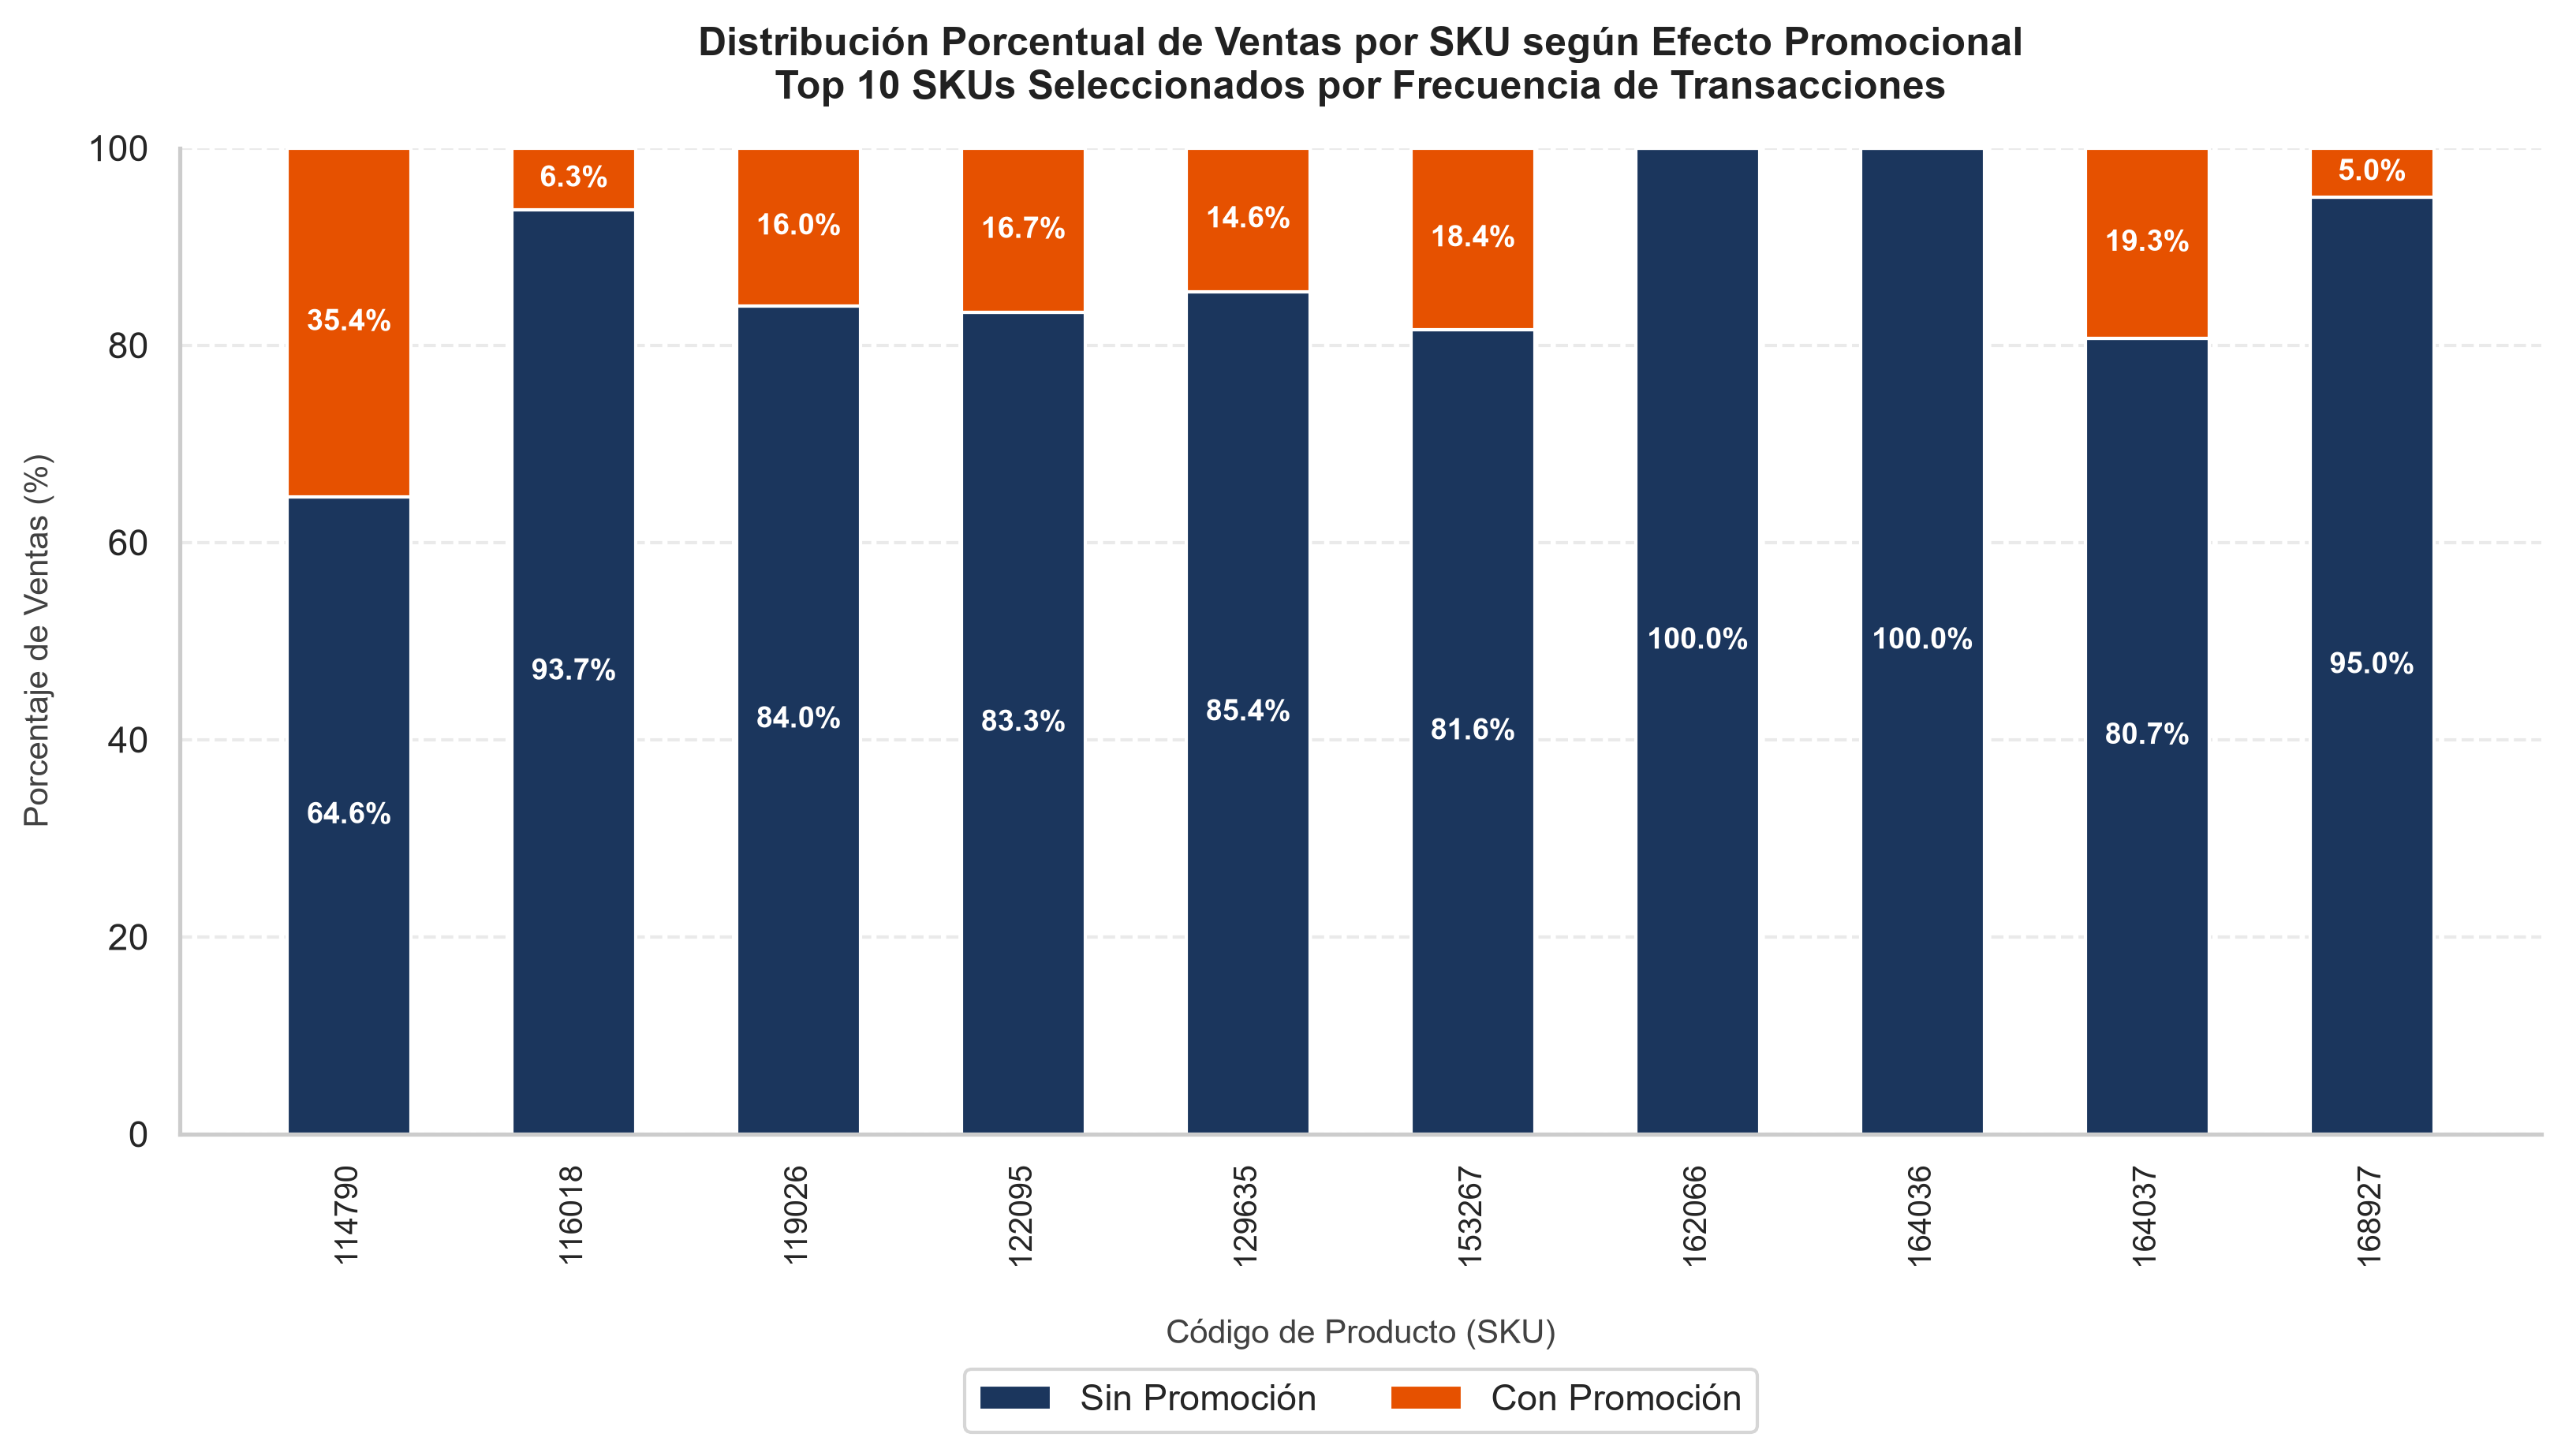

In [ ]:
import matplotlib.pyplot as plt

# 1. Seleccionar los 10 SKUs principales por FRECUENCIA DE TRANSACCIONES (Criterio del Profesor)
top_10_skus = (
    bbdd_final_75.groupby("item_nbr")["unit_sales"]
    .count()
    .nlargest(10)
    .index.tolist()
)

# 2. Filtrar la base de datos final para estos 10 SKUs
df_top10 = bbdd_final_75[bbdd_final_75["item_nbr"].isin(top_10_skus)].copy()

# 3. Agrupar ventas por SKU y por estado de promoción (False vs True)
ventas_promo = (
    df_top10.groupby(["item_nbr", "onpromotion"])["unit_sales"]
    .sum()
    .unstack(fill_value=0)
)

# Asegurar que existan ambas columnas (False y True)
if True not in ventas_promo.columns:
    ventas_promo[True] = 0
if False not in ventas_promo.columns:
    ventas_promo[False] = 0

# Calcular total y porcentajes dentro de cada SKU
ventas_promo["total_sales"] = ventas_promo[True] + ventas_promo[False]
ventas_promo["pct_no_promo"] = (ventas_promo[False] / ventas_promo["total_sales"]) * 100
ventas_promo["pct_promo"] = (ventas_promo[True] / ventas_promo["total_sales"]) * 100

# Reordenar según el orden exacto del Top 10 por frecuencia
ventas_promo = ventas_promo.loc[top_10_skus]

# Datos para el gráfico
skus = [str(sku) for sku in ventas_promo.index]
val_no_promo = ventas_promo["pct_no_promo"].values
val_promo = ventas_promo["pct_promo"].values

# 4. Creación del gráfico de barras apiladas verticales al 100%
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=300)

# Barras verticales apiladas al 100%
bar1 = ax.bar(skus, val_no_promo, label="Sin Promoción", color="#1B365D", width=0.55)
bar2 = ax.bar(skus, val_promo, bottom=val_no_promo, label="Con Promoción", color="#E65100", width=0.55)

# Agregar etiquetas porcentuales dentro de las barras verticales
for i in range(len(skus)):
    # Porcentaje Sin Promoción
    if val_no_promo[i] > 5:
        ax.text(
            i, val_no_promo[i] / 2, 
            f"{val_no_promo[i]:.1f}%", 
            ha="center", va="center", color="white", fontsize=9, fontweight="bold"
        )
    # Porcentaje Con Promoción (solo si es visible)
    if val_promo[i] > 2:
        ax.text(
            i, val_no_promo[i] + (val_promo[i] / 2), 
            f"{val_promo[i]:.1f}%", 
            ha="center", va="center", color="white", fontsize=9, fontweight="bold"
        )

# Títulos y nombres de ejes
ax.set_title(
    "Distribución Porcentual de Ventas por SKU según Efecto Promocional\nTop 10 SKUs Seleccionados por Frecuencia de Transacciones", 
    fontsize=12, fontweight="bold", pad=15, color="#212121"
)
ax.set_ylabel("Porcentaje de Ventas (%)", fontsize=10, labelpad=10, color="#424242")
ax.set_xlabel("Código de Producto (SKU)", fontsize=10, labelpad=15, color="#424242")

ax.set_ylim(0, 100)

# Rotar las etiquetas de los SKUs verticalmente para que no se sobrepongan
plt.xticks(rotation=90, ha='center', fontsize=9.5)

# Limpieza estética del gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)

# Leyenda ejecutiva ajustada para no colisionar con el eje X
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.22), 
    ncol=2, 
    frameon=True, 
    facecolor'#ffffff', 
    edgecolor='#cccccc'
)

plt.tight_layout()
plt.show()

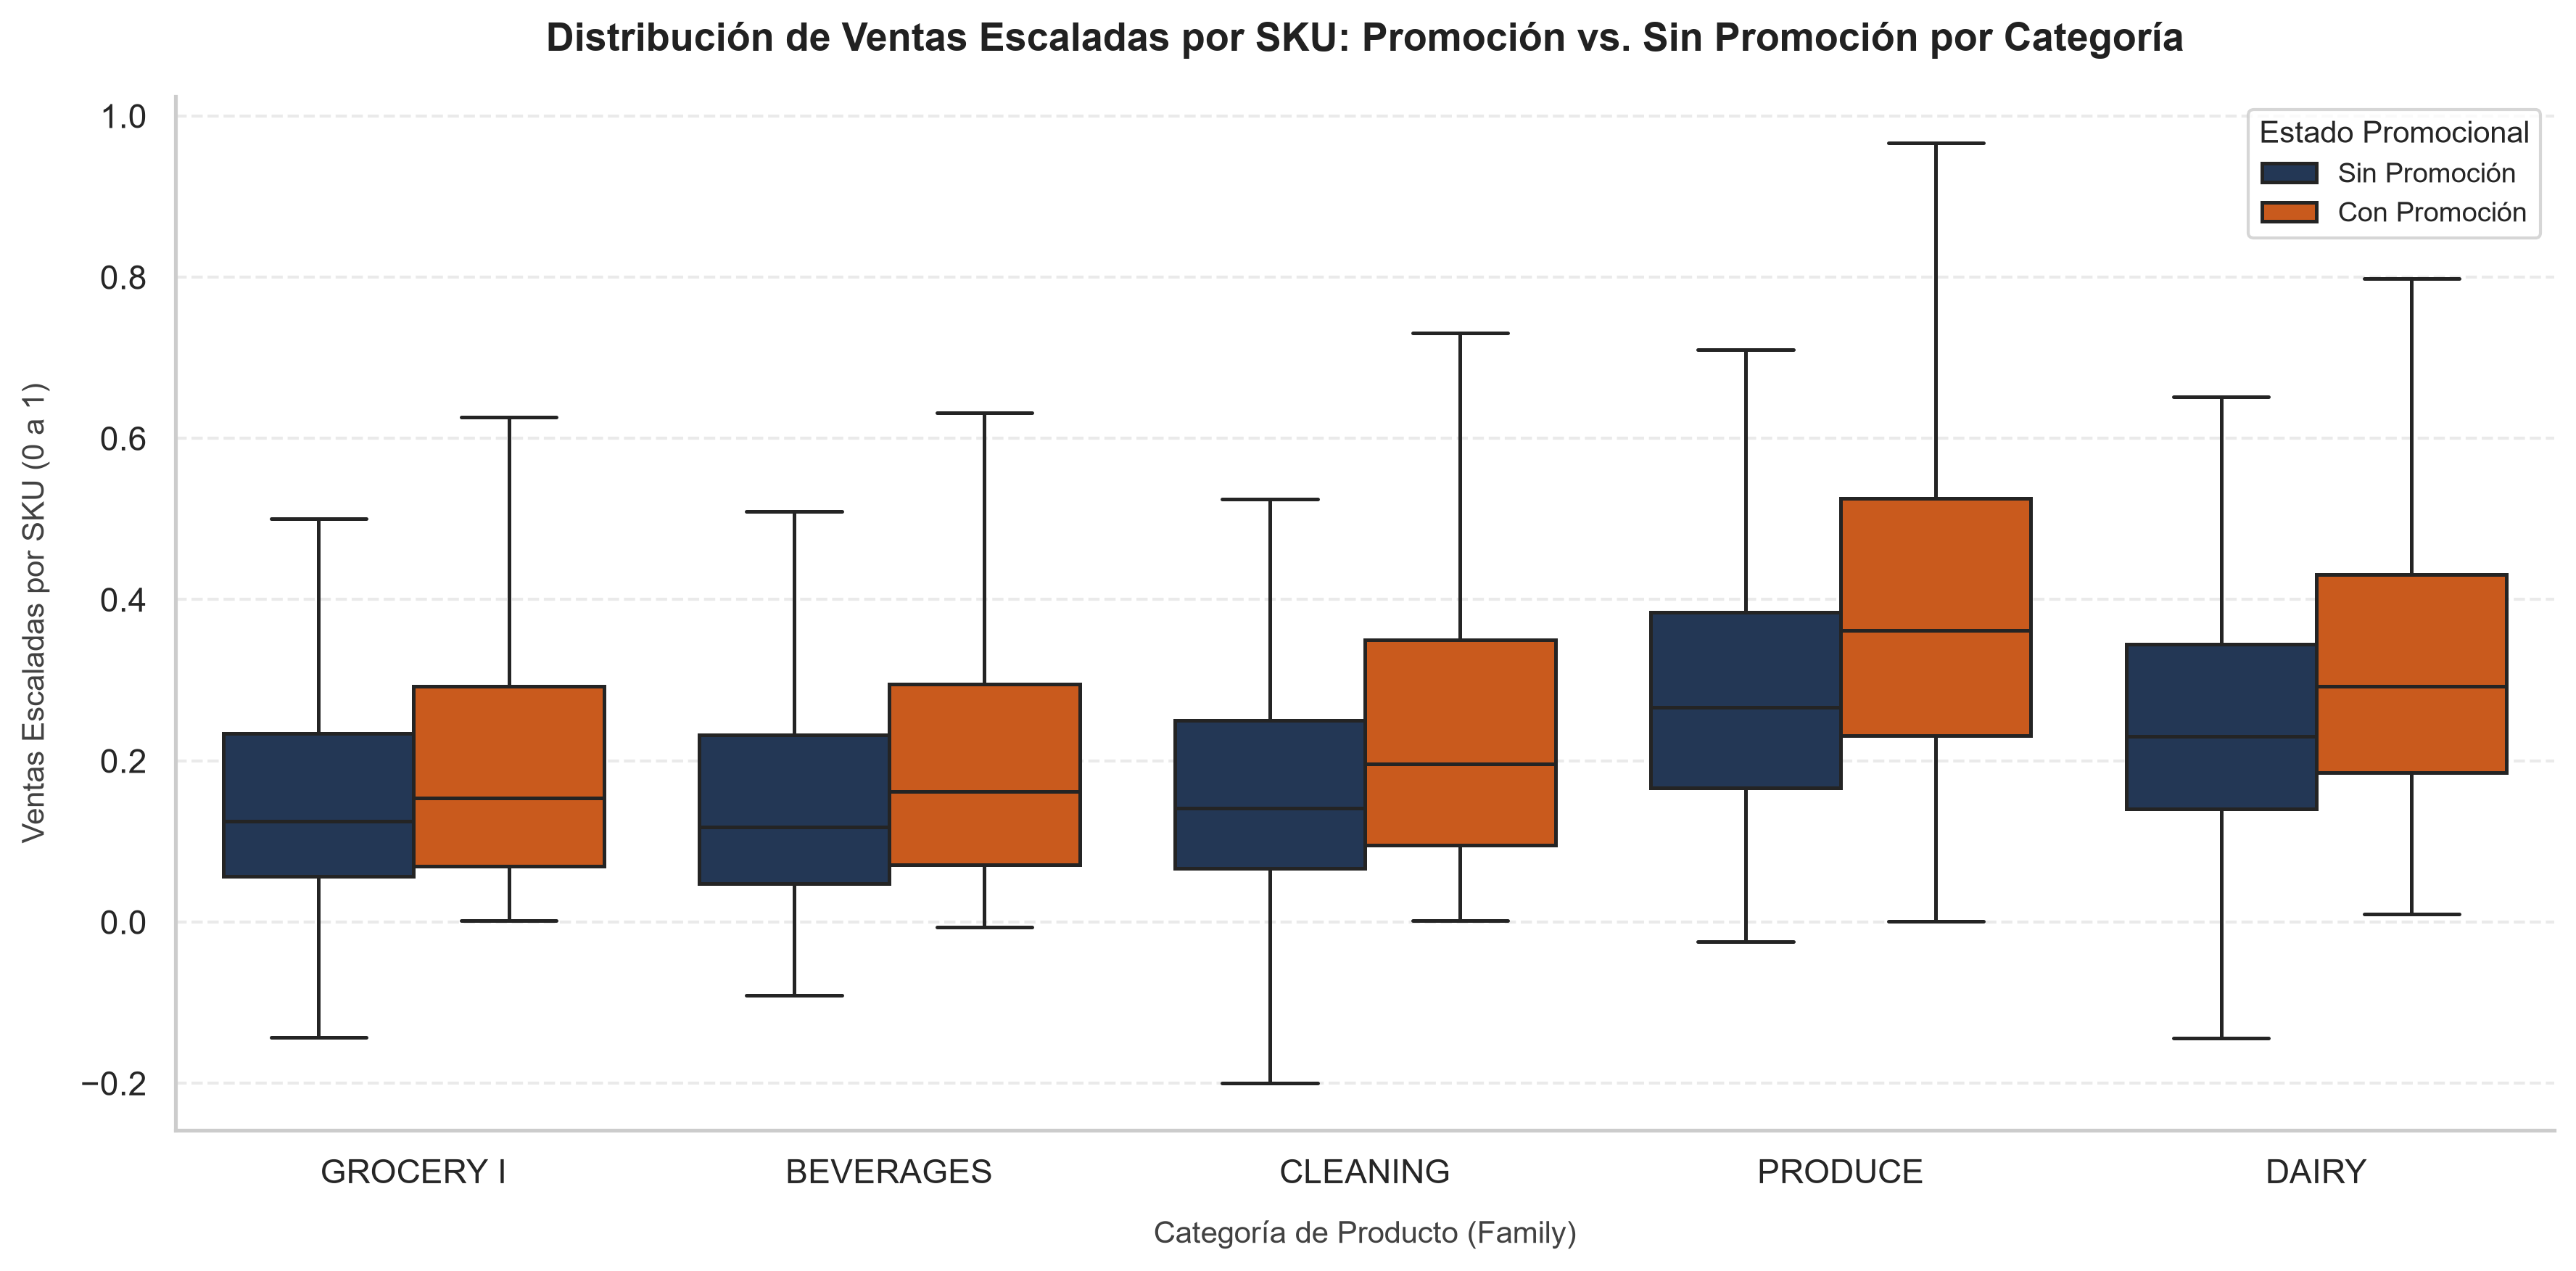

In [ ]:
# diagrama de caja - boxplot: ventas con promocion versus sin promocion
sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = 'Arial'

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Mapeo de nombres para la leyenda de promoción
df_boxplot = bbdd_final_75.copy()
df_boxplot["Estado Promoción"] = df_boxplot["onpromotion"].map({True: "Con Promoción", False: "Sin Promoción"})

# Paleta ejecutiva
paleta_box = {"Sin Promoción": "#1B365D", "Con Promoción": "#E65100"}

# Boxplot agrupado por Categoría y Estado de Promoción
sns.boxplot(
    data=df_boxplot,
    x="family",
    y="unit_sales_scaled_sku",
    hue="Estado Promoción",
    palette=paleta_box,
    showfliers=False,  # Oculta outliers extremos para ver claramente mediana y cuartiles
    linewidth=1.2,
    ax=ax
)

# Títulos y etiquetas
ax.set_title(
    "Distribución de Ventas Escaladas por SKU: Promoción vs. Sin Promoción por Categoría", 
    fontsize=13, fontweight='bold', pad=15, color="#212121"
)
ax.set_xlabel("Categoría de Producto (Family)", fontsize=10, labelpad=10, color="#424242")
ax.set_ylabel("Ventas Escaladas por SKU (0 a 1)", fontsize=10, labelpad=10, color="#424242")

# Estética de bordes y rejilla
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)

# Leyenda ejecutiva
ax.legend(
    title="Estado Promocional", 
    title_fontsize='10', 
    fontsize='9', 
    frameon=True, 
    facecolor='#ffffff', 
    edgecolor='#cccccc',
    loc='upper right'
)

plt.tight_layout()
plt.show()

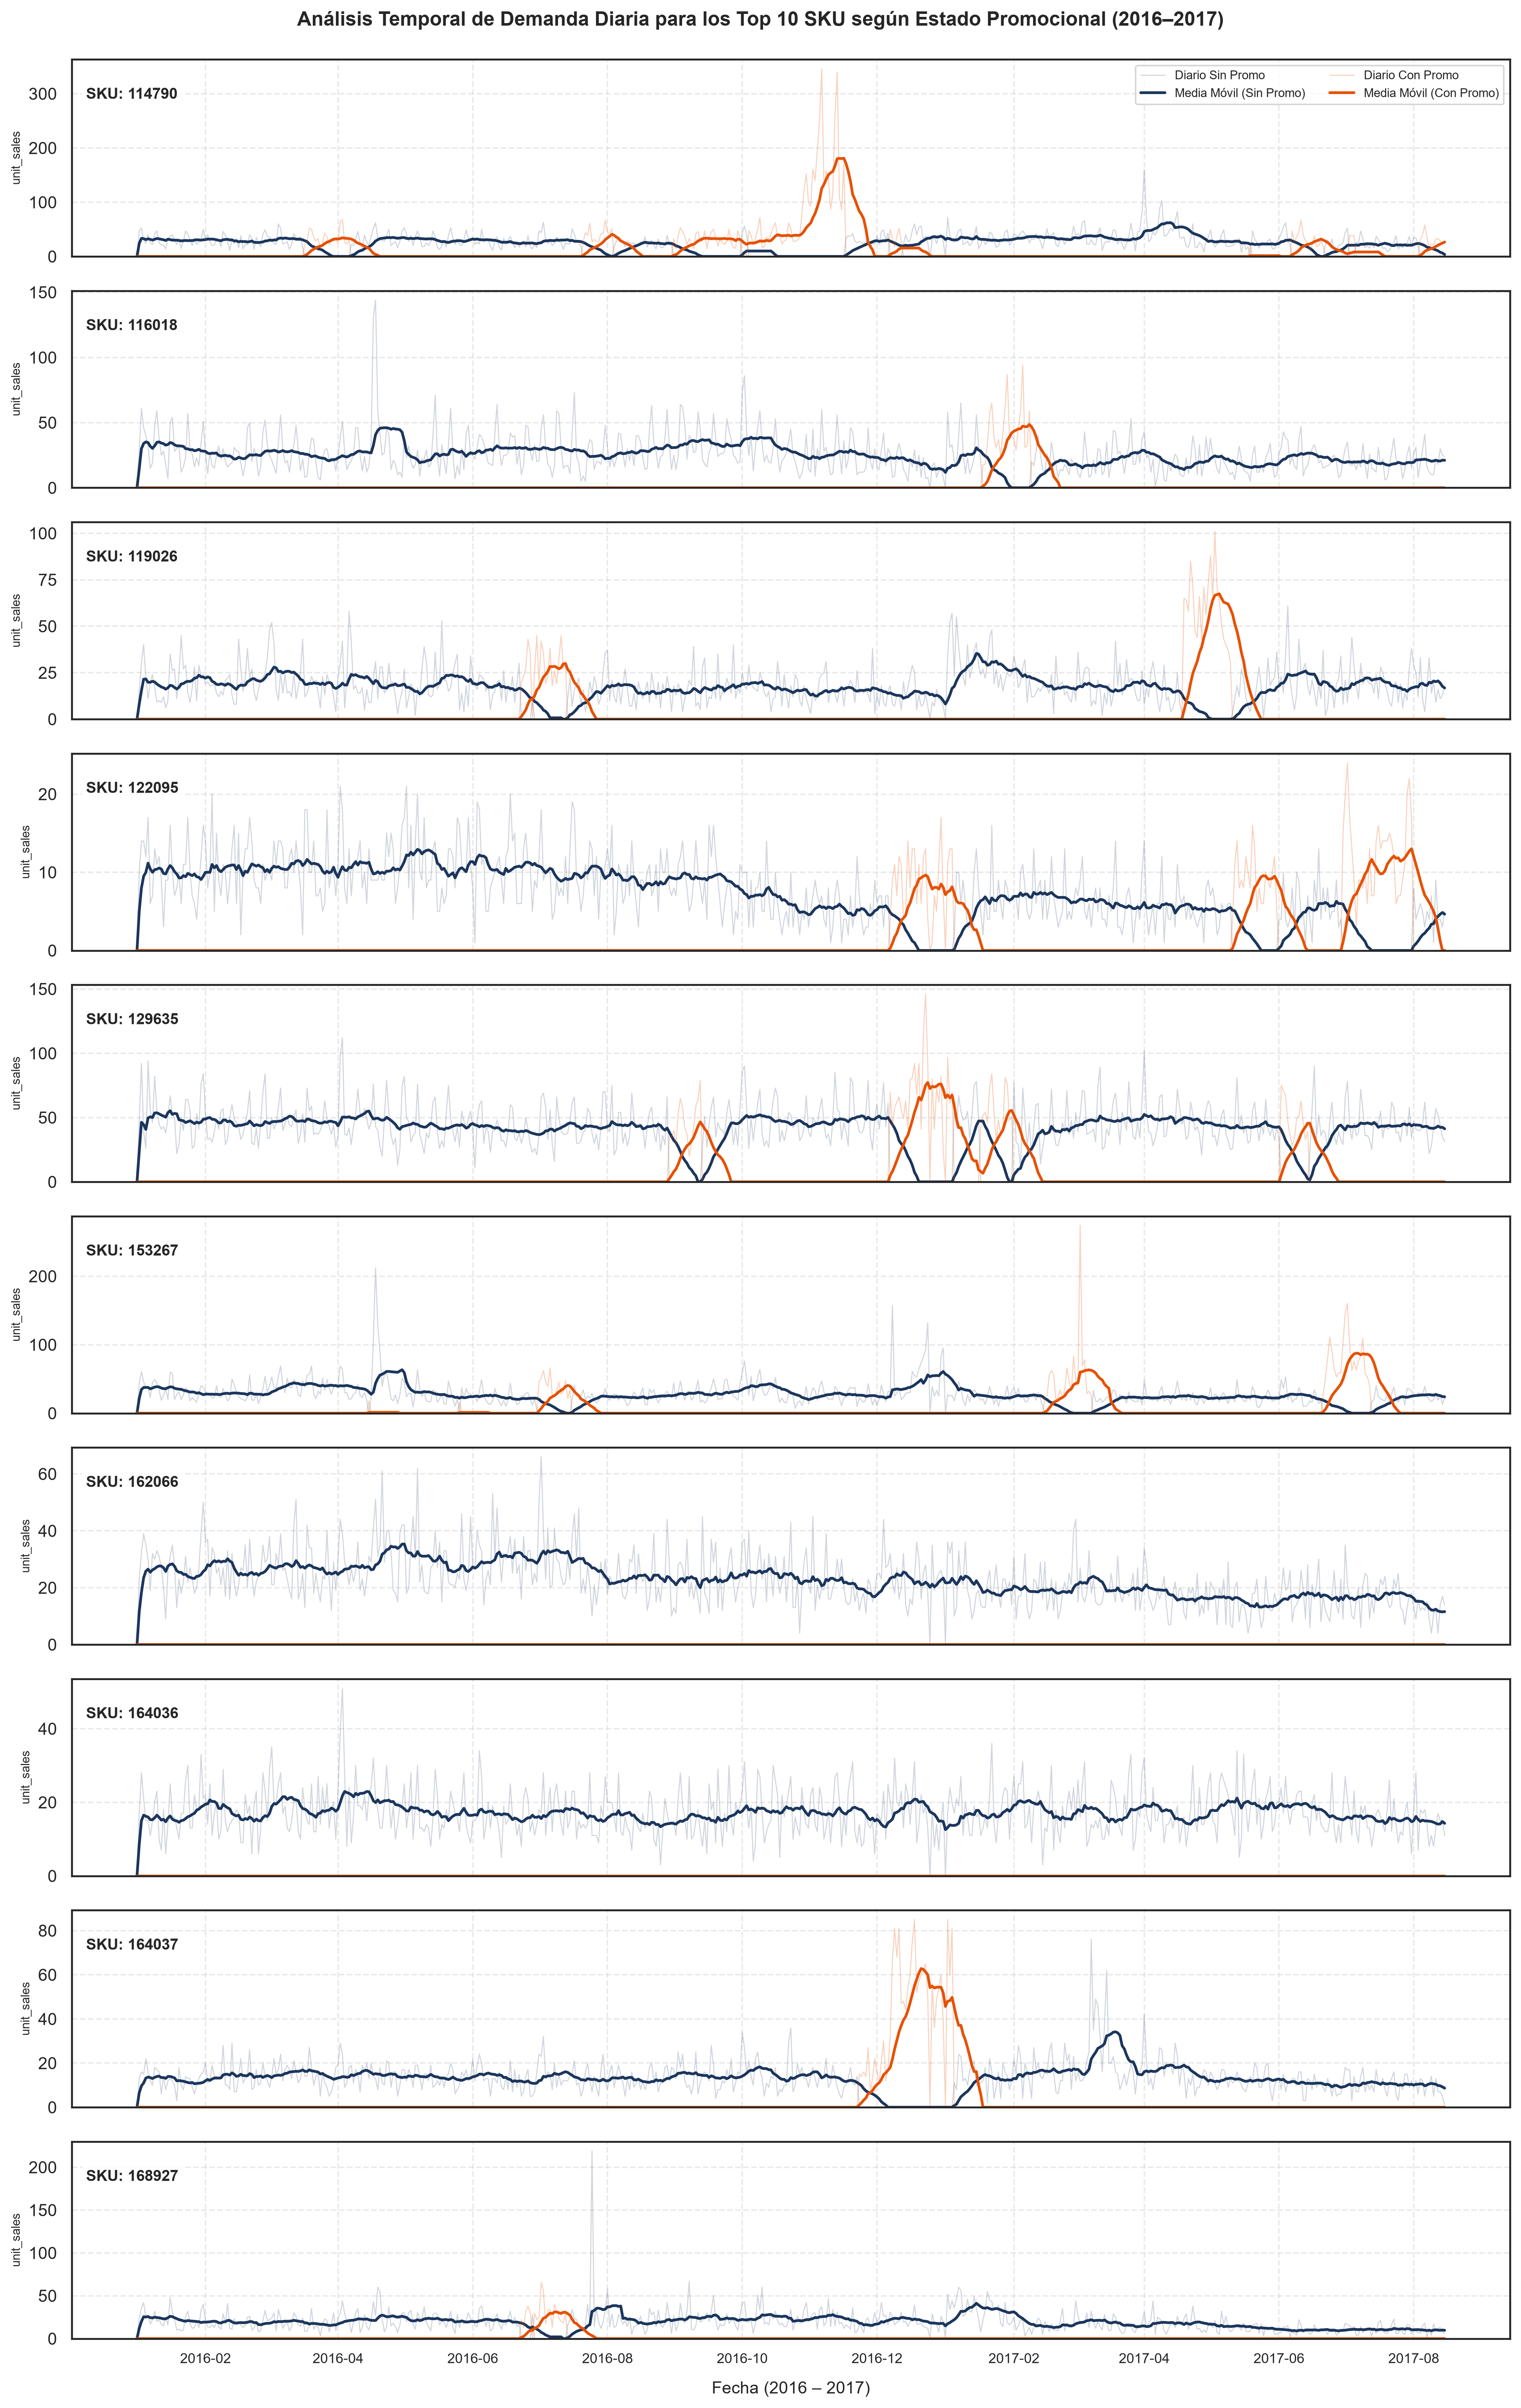

In [108]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# 1. Asegurar formato de fecha y booleano para promoción en bbdd_final_75
bbdd_final_75["date"] = pd.to_datetime(bbdd_final_75["date"])
bbdd_final_75["onpromotion"] = bbdd_final_75["onpromotion"].astype(bool)

# 2. Seleccionar los 10 SKUs principales por FRECUENCIA DE TRANSACCIONES (Criterio consistente)
top_10_skus = (
    bbdd_final_75.groupby("item_nbr")["unit_sales"]
    .count()
    .nlargest(10)
    .index.tolist()
)

# 3. Filtrar para el período 2016–2017 y los 10 SKU seleccionados
df_ts = bbdd_final_75[
    (bbdd_final_75["item_nbr"].isin(top_10_skus))
    & (bbdd_final_75["date"].dt.year.isin([2016, 2017]))
].copy()

# 4. Agregación diaria por date + item_nbr + onpromotion (Separando Con Promo vs Sin Promo)
ts_diaria = (
    df_ts.groupby(["date", "item_nbr", "onpromotion"])["unit_sales"]
    .sum()
    .unstack(level="onpromotion", fill_value=0)
    .reset_index()
)

# Asegurar que existan las columnas False (Sin Promo) y True (Con Promo)
if False not in ts_diaria.columns:
    ts_diaria[False] = 0
if True not in ts_diaria.columns:
    ts_diaria[True] = 0

ts_diaria.rename(columns={False: "sin_promo", True: "con_promo"}, inplace=True)

# 5. Crear estructura de subgráficos (10 filas x 1 columna)
fig, axes = plt.subplots(
    nrows=10, ncols=1, figsize=(14, 22), sharex=True, dpi=300
)

# Colores ejecutivos alineados
color_no_promo = "#1B365D"  # Azul marino (Sin promoción)
color_promo = "#E65100"     # Naranja (Con promoción)

# Rango completo de fechas para rellenar vacíos cronológicos
rango_fechas = pd.date_range(start="2016-01-01", end="2017-08-15")

for i, sku in enumerate(top_10_skus):
    ax = axes[i]

    # Subconjunto por SKU y orden cronológico
    df_sku = ts_diaria[ts_diaria["item_nbr"] == sku].sort_values("date")

    # Rellenar días sin registros con 0
    df_sku = (
        df_sku.set_index("date")
        .reindex(rango_fechas, fill_value=0)
        .reset_index()
    )
    df_sku.rename(columns={"index": "date"}, inplace=True)

    # Media móvil de 14 días para cada serie
    df_sku["rolling_sin_promo"] = df_sku["sin_promo"].rolling(window=14, min_periods=1).mean()
    df_sku["rolling_con_promo"] = df_sku["con_promo"].rolling(window=14, min_periods=1).mean()

    # Etiqueta de SKU
    ax.text(
        0.01,
        0.80,
        f"SKU: {sku}",
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none"),
    )

    # --- SERIE SIN PROMOCIÓN ---
    ax.plot(
        df_sku["date"],
        df_sku["sin_promo"],
        color=color_no_promo,
        alpha=0.20,
        linewidth=0.7,
        label="Diario Sin Promo",
    )
    ax.plot(
        df_sku["date"],
        df_sku["rolling_sin_promo"],
        color=color_no_promo,
        linewidth=1.8,
        label="Media Móvil (Sin Promo)",
    )

    # --- SERIE CON PROMOCIÓN ---
    ax.plot(
        df_sku["date"],
        df_sku["con_promo"],
        color=color_promo,
        alpha=0.25,
        linewidth=0.7,
        label="Diario Con Promo",
    )
    ax.plot(
        df_sku["date"],
        df_sku["rolling_con_promo"],
        color=color_promo,
        linewidth=1.8,
        label="Media Móvil (Con Promo)",
    )

    # Ajustes estéticos
    ax.set_ylabel("unit_sales", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylim(bottom=0)

    # Leyenda en el primer panel
    if i == 0:
        ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", ncol=2)

# Configuración del eje X global
axes[-1].set_xlabel("Fecha (2016 – 2017)", fontsize=11, labelpad=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=0, fontsize=9)

# Título Principal
fig.suptitle(
    "Análisis Temporal de Demanda Diaria para los Top 10 SKU según Estado Promocional (2016–2017)",
    fontsize=13,
    fontweight="bold",
    y=0.995,
)

plt.tight_layout()
plt.subplots_adjust(top=0.975)
plt.show()

## Guardar el resultado

In [109]:
OUTPUT_PATH = os.path.join(BASE_DIR, "bbdd_filtrada.csv")
bbdd_filtrada.to_csv(OUTPUT_PATH, index=False)
print("Guardado en:", OUTPUT_PATH)


Guardado en: .\bbdd_filtrada.csv
